# Sparkov Credit Card Fraud — Experiment Notebook

**Dataset:** [Kaggle - kartik2112/fraud-detection](https://www.kaggle.com/datasets/kartik2112/fraud-detection)
**Goal:** Compare baseline vs tuned models, ensemble, and pick the best production candidate.
**Strategy:** Data-driven EDA → EDA-informed features → honest time-based split → baseline → tuned → ensemble.

**Why this structure?**
- No leakage: target encodings and rolling features all fit on **train** only, mapped to val/test.
- Honest evaluation: val is the *last* slice of the train period (most recent), test is the future holdout.


In [77]:
# ── Colab: install dependencies ─────────────────────────────────────────
!pip install -q catboost lightgbm xgboost mlflow dagshub \
             imbalanced-learn shap scipy scikit-learn 2>&1 | tail -5
print('✅ Packages installed')


✅ Packages installed


In [78]:
# ── Colab: Mount Drive + auto-detect GPU ────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import subprocess
try:
    subprocess.check_output('nvidia-smi', stderr=subprocess.DEVNULL)
    DEVICE = 'GPU'
except Exception:
    DEVICE = 'CPU'
print(f'✅ Runtime device: {DEVICE}')

# ── Data paths — adjust DATA_DIR to match your Drive folder ─────────────
DATA_DIR   = '/content/drive/MyDrive/data/fraud'
TRAIN_PATH = f'{DATA_DIR}/fraudTrain.csv'
TEST_PATH  = f'{DATA_DIR}/fraudTest.csv'
print(f'Train → {TRAIN_PATH}')
print(f'Test  → {TEST_PATH}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Runtime device: GPU
Train → /content/drive/MyDrive/data/fraud/fraudTrain.csv
Test  → /content/drive/MyDrive/data/fraud/fraudTest.csv


In [ ]:
# ⚠️  DELETE Token ,remember ⚠️
import os
os.environ['DAGSHUB_TOKEN']            = 'd82ecb14a862f80118d9a45fe83a855812420fc5'
os.environ['MLFLOW_TRACKING_URI']      = 'https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow'
os.environ['MLFLOW_TRACKING_USERNAME'] = os.environ['DAGSHUB_TOKEN']
os.environ['MLFLOW_TRACKING_PASSWORD'] = os.environ['DAGSHUB_TOKEN']
print('Env vars set')


✅ Env vars set


In [80]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix,
                             classification_report,
                             fbeta_score, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import TimeSeriesSplit
import catboost as cb
import matplotlib.pyplot as plt
import time, gc, warnings
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.catboost
warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 100)
%matplotlib inline
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.calibration import calibration_curve
import shap


In [81]:
# MLflow setup
import os
os.environ['MLFLOW_TRACKING_USERNAME'] = os.getenv('DAGSHUB_TOKEN', '')
os.environ['MLFLOW_TRACKING_PASSWORD'] = os.getenv('DAGSHUB_TOKEN', '')
mlflow.set_tracking_uri("https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow")
mlflow.set_experiment("sparkov-experiments")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")


MLflow tracking URI: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow


In [82]:
# ── 1. Load data ─────────────────────────────────────────────────────────
# TRAIN_PATH / TEST_PATH are set in the Drive mount cell above.
# If running locally swap them back to:
#   TRAIN_PATH = '../data/raw/fraudTrain.csv'
#   TEST_PATH  = '../data/raw/fraudTest.csv'

train_full = pd.read_csv(TRAIN_PATH).drop(columns=['Unnamed: 0'])
test_full  = pd.read_csv(TEST_PATH ).drop(columns=['Unnamed: 0'])

train_full['trans_date_trans_time'] = pd.to_datetime(train_full['trans_date_trans_time'])
test_full ['trans_date_trans_time'] = pd.to_datetime(test_full ['trans_date_trans_time'])

print(f"Train : {train_full.shape[0]:>9,} rows | fraud: {train_full.is_fraud.sum():>5,} ({train_full.is_fraud.mean():.4%})")
print(f"Test  : {test_full.shape[0]:>9,} rows | fraud: {test_full.is_fraud.sum():>5,} ({test_full.is_fraud.mean():.4%})")
print(f"Train window: {train_full.trans_date_trans_time.min()} -> {train_full.trans_date_trans_time.max()}")
print(f"Test  window: {test_full.trans_date_trans_time.min()} -> {test_full.trans_date_trans_time.max()}")


Train : 1,296,675 rows | fraud: 7,506 (0.5789%)
Test  :   555,719 rows | fraud: 2,145 (0.3860%)
Train window: 2019-01-01 00:00:18 -> 2020-06-21 12:13:37
Test  window: 2020-06-21 12:14:25 -> 2020-12-31 23:59:34


**Key EDA findings that drive the features below:**
- Fraud rate varies by **hour** (highest late night, lowest early morning).
- Fraud rate varies by **category** (`shopping_net`, `misc_net` are high-risk).
- Fraud rate is **U-shaped in amount** (small + very large amounts more risky).
- **Distance** between cardholder and merchant is a strong signal.
- **Cardholder age** matters (younger + older more vulnerable).
- **Repeat merchants** are safer than first-time ones.

These drive the features in the next section.


In [83]:
#2. Time-based split: hold out last 20% of train as val
# Rationale: the val set should be the most-recent slice of train, so the
# model is tuned on patterns closest to the deployment window (2020 H2).
train_full = train_full.sort_values('trans_date_trans_time').reset_index(drop=True)
cutoff = train_full['trans_date_trans_time'].quantile(0.80)
val_df   = train_full[train_full['trans_date_trans_time'] >= cutoff].reset_index(drop=True)
train_df = train_full[train_full['trans_date_trans_time'] <  cutoff].reset_index(drop=True)

print(f"Train : {len(train_df):>9,} | fraud: {train_df.is_fraud.sum():>4,} ({train_df.is_fraud.mean():.4%}) | {train_df.trans_date_trans_time.min()} -> {train_df.trans_date_trans_time.max()}")
print(f"Val   : {len(val_df):>9,} | fraud: {val_df.is_fraud.sum():>4,} ({val_df.is_fraud.mean():.4%}) | {val_df.trans_date_trans_time.min()} -> {val_df.trans_date_trans_time.max()}")
print(f"Test  : {len(test_full):>9,} | fraud: {test_full.is_fraud.sum():>4,} ({test_full.is_fraud.mean():.4%}) | {test_full.trans_date_trans_time.min()} -> {test_full.trans_date_trans_time.max()}")


Train : 1,037,340 | fraud: 5,968 (0.5753%) | 2019-01-01 00:00:18 -> 2020-03-06 07:15:17
Val   :   259,335 | fraud: 1,538 (0.5931%) | 2020-03-06 07:16:43 -> 2020-06-21 12:13:37
Test  :   555,719 | fraud: 2,145 (0.3860%) | 2020-06-21 12:14:25 -> 2020-12-31 23:59:34


## Feature Engineering

**I follow this rules so features has no leakage**
1. **Time features** come from `trans_date_trans_time` directly so no leakage.
2. **Age** comes from `dob` — computed at transaction time.
3. **Distance** is Haversine between `(lat, long)` and `(merch_lat, merch_long)`.
4. **Frequency encodings** use train+val+test together (count is a valid non leaking feature).
5. **Target encodings** will fit on `train_df` only mapped to val/test via `merge`.
6. **Velocity features** are rolling counts per `cc_num`  computed per split so no future leakage.


In [84]:
# 3a. Core feature engineering (applied to all splits)
def build_base_features(df):
    df = df.copy()
    # Time
    df['hour']     = df['trans_date_trans_time'].dt.hour.astype('int8')
    df['dow']      = df['trans_date_trans_time'].dt.dayofweek.astype('int8')
    df['month']    = df['trans_date_trans_time'].dt.month.astype('int8')
    df['is_night'] = df['hour'].isin([0,1,2,3,4,22,23]).astype('int8')
    # Age at transaction time
    df['dob']      = pd.to_datetime(df['dob'])
    df['age']      = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype('float32')
    # Amount transforms
    df['amt_log']  = np.log1p(df['amt']).astype('float32')
    df['amt_is_round'] = (df['amt'] == df['amt'].round(0)).astype('int8')
    # Haversine distance (cardholder <-> merchant), in km
    R = 6371.0
    lat1, lon1 = np.radians(df['lat']),     np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    df['distance_km'] = (2 * R * np.arcsin(np.sqrt(a))).astype('float32')
    return df

train_df = build_base_features(train_df)
val_df   = build_base_features(val_df)
test_df  = build_base_features(test_full)
print("Base features done")
print(f"  new cols: hour, dow, month, is_night, age, amt_log, amt_is_round, distance_km")


Base features done
  new cols: hour, dow, month, is_night, age, amt_log, amt_is_round, distance_km


In [85]:
#  3b. Frequency encodings (count-based, leak-free)
# Concatenate all splits to count, then map back. This is safe because
# counts do not depend on the target.
combined = pd.concat([train_df, val_df, test_df], ignore_index=True)
for col in ['cc_num', 'merchant', 'category', 'city', 'state', 'job', 'zip']:
    counts = combined[col].value_counts().to_dict()
    for d in (train_df, val_df, test_df):
        d[f'{col}_FE'] = d[col].map(counts).astype('float32')

print("Frequency encodings done")
print(f"  added: cc_num_FE, merchant_FE, category_FE, city_FE, state_FE, job_FE, zip_FE")
del combined
gc.collect()


Frequency encodings done
  added: cc_num_FE, merchant_FE, category_FE, city_FE, state_FE, job_FE, zip_FE


570

In [86]:
#  3c. Target encodings (fit on train only)
# Smoothed mean encoding. Shrinks rare categories toward the global rate
# to prevent overfitting on low-count merchants.
GLOBAL = train_df['is_fraud'].mean()
SMOOTHING = 50.0  # higher = more shrinkage to global mean

for col in ['merchant', 'category', 'city', 'state', 'job']:
    stats = train_df.groupby(col)['is_fraud'].agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + GLOBAL * SMOOTHING) / (stats['count'] + SMOOTHING)
    smoothed = smoothed.to_dict()
    for d in (train_df, val_df, test_df):
        d[f'{col}_te'] = d[col].map(smoothed).fillna(GLOBAL).astype('float32')

print(f"Target encodings done (smoothing={SMOOTHING}, global_fraud={GLOBAL:.4%})")
print(f"  added: merchant_te, category_te, city_te, state_te, job_te")

#  3c-bis. Amount stat features (per-group, leak-free)
# Mean and std of amount per group, computed on train only. These let the
# model judge "is this amount unusual for this merchant / category / card?"
for col in ['merchant', 'category', 'cc_num']:
    stats = train_df.groupby(col)['amt'].agg(['mean', 'std'])
    for stat in ['mean', 'std']:
        colname = f'amt_per_{col}_{stat}'
        mapping = stats[stat].to_dict()
        fallback = train_df['amt'].mean() if stat == 'mean' else train_df['amt'].std()
        for d in (train_df, val_df, test_df):
            d[colname] = d[col].map(mapping).fillna(fallback).astype('float32')

print("Amount stat features done")
print("  added: amt_per_merchant_mean/std, amt_per_category_mean/std, amt_per_cc_num_mean/std")



Target encodings done (smoothing=50.0, global_fraud=0.5753%)
  added: merchant_te, category_te, city_te, state_te, job_te
Amount stat features done
  added: amt_per_merchant_mean/std, amt_per_category_mean/std, amt_per_cc_num_mean/std


In [87]:
# 3d. Velocity features (count of prior txns per cc_num)
# Rolling count over time windows. Per-split computation prevents future leakage.
def add_velocity(df, window_hours_list):
    df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
    df['ts']     = df['trans_date_trans_time'].astype('int64') // 10**9
    for h in window_hours_list:
        window_sec = h * 3600
        # Count of PRIOR transactions within `h` hours, per cc_num
        df[f'txn_last_{h}h'] = (
            df.groupby('cc_num')['ts']
              .transform(lambda s: s.searchsorted(s.values - h*3600, side='right') - 1)
              .astype('float32')
        )
        # Sum of amt for PRIOR transactions within `h` hours, per cc_num.
        # Use cumsum + searchsorted: O(N) per group, index-aligned.
        amt_sums = np.zeros(len(df), dtype='float32')
        for _, g in df.groupby('cc_num', sort=False):
            ts  = g['ts'].values
            amt = g['amt'].values
            idx = g.index.values
            n   = len(g)
            cum_amt = np.concatenate([[0.0], np.cumsum(amt, dtype='float64')])
            for i in range(n):
                j = np.searchsorted(ts[:i+1], ts[i] - window_sec, side='left')
                amt_sums[idx[i]] = cum_amt[i] - cum_amt[j]
        df[f'amt_sum_last_{h}h'] = amt_sums
    return df.drop(columns=['ts'])

train_df = add_velocity(train_df, [1, 24, 168])  # 1h, 24h, 7d
val_df   = add_velocity(val_df,   [1, 24, 168])
test_df  = add_velocity(test_df,  [1, 24, 168])
print("Velocity features done:")
print("  counts : txn_last_1h, txn_last_24h, txn_last_168h")
print("  sums   : amt_sum_last_1h, amt_sum_last_24h, amt_sum_last_168h")


Velocity features done:
  counts : txn_last_1h, txn_last_24h, txn_last_168h
  sums   : amt_sum_last_1h, amt_sum_last_24h, amt_sum_last_168h


In [88]:
#3e. Assemble feature matrix
DROP = ['trans_date_trans_time', 'first', 'last', 'street', 'dob',
        'trans_num', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long',
        'cc_num', 'merchant', 'category', 'city', 'state', 'job', 'gender', 'zip',
        'is_fraud']
FEATURES = [c for c in train_df.columns if c not in DROP]
print(f"Total features: {len(FEATURES)}")
print(FEATURES)

X_train, y_train = train_df[FEATURES].values, train_df['is_fraud'].values
X_val,   y_val   = val_df  [FEATURES].values, val_df  ['is_fraud'].values
X_test,  y_test  = test_df [FEATURES].values, test_df ['is_fraud'].values

del train_df, val_df, test_df, train_full, test_full
gc.collect()
print(f"\nX_train: {X_train.shape} | fraud: {y_train.mean():.4%}")
print(f"X_val  : {X_val.shape} | fraud: {y_val.mean():.4%}")
print(f"X_test : {X_test.shape} | fraud: {y_test.mean():.4%}")


Total features: 34
['amt', 'city_pop', 'hour', 'dow', 'month', 'is_night', 'age', 'amt_log', 'amt_is_round', 'distance_km', 'cc_num_FE', 'merchant_FE', 'category_FE', 'city_FE', 'state_FE', 'job_FE', 'zip_FE', 'merchant_te', 'category_te', 'city_te', 'state_te', 'job_te', 'amt_per_merchant_mean', 'amt_per_merchant_std', 'amt_per_category_mean', 'amt_per_category_std', 'amt_per_cc_num_mean', 'amt_per_cc_num_std', 'txn_last_1h', 'amt_sum_last_1h', 'txn_last_24h', 'amt_sum_last_24h', 'txn_last_168h', 'amt_sum_last_168h']

X_train: (1037340, 34) | fraud: 0.5753%
X_val  : (259335, 34) | fraud: 0.5931%
X_test : (555719, 34) | fraud: 0.3860%


## Baseline Models

Default hyperparameters for LightGBM and XGBoost and catboost


In [89]:
# ── 4. OOF setup: TimeSeriesSplit (5 folds, expanding window) ───────────
# Why time-series split: random K-fold would let the model see future
# transactions to predict past ones — invalid for fraud detection. The
# expanding window respects temporal order, so each fold's predictions
# are made by a model that only saw earlier data.

tscv = TimeSeriesSplit(n_splits=5)
results = {}  # populated by all OOF cells below
print(f'TimeSeriesSplit: {tscv.n_splits} folds, expanding window')
for fold, (tr, vl) in enumerate(tscv.split(X_train)):
    print(f'  Fold {fold+1}: train={len(tr):>9,}  val={len(vl):>9,}')


TimeSeriesSplit: 5 folds, expanding window
  Fold 1: train=  172,890  val=  172,890
  Fold 2: train=  345,780  val=  172,890
  Fold 3: train=  518,670  val=  172,890
  Fold 4: train=  691,560  val=  172,890
  Fold 5: train=  864,450  val=  172,890


In [90]:
#  5a. LightGBM baseline — OOF 
with mlflow.start_run(run_name="lgb-baseline"):
    mlflow.log_params({"model": "LightGBM", "variant": "baseline", "n_estimators": 500, "learning_rate": 0.1, "num_leaves": 31})
    t0 = time.time()
    oof_lgb_base = np.zeros(len(X_train))
    test_proba_lgb_base = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.1, num_leaves=31,
                                objective='binary', verbose=-1, random_state=42, n_jobs=-1)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof_lgb_base[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_lgb_base += m.predict_proba(X_test)[:, 1] / tscv.n_splits
        
    results['lgb_base_oof_pr']  = average_precision_score(y_train, oof_lgb_base)
    results['lgb_base_test_pr'] = average_precision_score(y_test,  test_proba_lgb_base)
    results['lgb_base_test_roc'] = roc_auc_score(y_test, test_proba_lgb_base)
    results['lgb_base_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["lgb_base_oof_pr"], "test_pr_auc": results["lgb_base_test_pr"], "test_roc_auc": results["lgb_base_test_roc"], "fit_time": results["lgb_base_time"]})
    mlflow.lightgbm.log_model(m, name="model")
    print(f'LGB baseline | OOF PR-AUC: {results["lgb_base_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["lgb_base_test_pr"]:.4f} | '
          f'time: {results["lgb_base_time"]:.1f}s')
lgb_base_model = m  # keep for feature importance


LGB baseline | OOF PR-AUC: 0.7040 | test PR-AUC: 0.7544 | time: 30.7s
🏃 View run lgb-baseline at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2/runs/003f44d26e584f9888fe8f39f09584c6
🧪 View experiment at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2


In [91]:
# 5b. XGBoost baseline — OOF
with mlflow.start_run(run_name="xgb-baseline"):
    mlflow.log_params({"model": "XGBoost", "variant": "baseline", "n_estimators": 500, "learning_rate": 0.1, "max_depth": 6})
    t0 = time.time()
    oof_xgb_base = np.zeros(len(X_train))
    test_proba_xgb_base = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=6,
                               tree_method='hist', eval_metric='aucpr',
                               early_stopping_rounds=50, random_state=42, n_jobs=-1)
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])], verbose=False)
        oof_xgb_base[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_xgb_base += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['xgb_base_oof_pr']  = average_precision_score(y_train, oof_xgb_base)
    results['xgb_base_test_pr'] = average_precision_score(y_test,  test_proba_xgb_base)
    results['xgb_base_test_roc'] = roc_auc_score(y_test, test_proba_xgb_base)
    results['xgb_base_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["xgb_base_oof_pr"], "test_pr_auc": results["xgb_base_test_pr"], "test_roc_auc": results["xgb_base_test_roc"], "fit_time": results["xgb_base_time"]})
    mlflow.xgboost.log_model(m, name="model")
    print(f'XGB baseline | OOF PR-AUC: {results["xgb_base_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["xgb_base_test_pr"]:.4f} | '
          f'time: {results["xgb_base_time"]:.1f}s')
xgb_base_model = m  # keep for feature importance


XGB baseline | OOF PR-AUC: 0.7937 | test PR-AUC: 0.6617 | time: 267.9s
🏃 View run xgb-baseline at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2/runs/15a11051cb774c0ab0caf59ac3c4ae70
🧪 View experiment at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2


In [92]:
# 6c. CatBoost — OOF
# CatBoost uses ordered boosting, which is a different inductive bias
with mlflow.start_run(run_name="catboost"):
    mlflow.log_params({"model": "CatBoost", "iterations": 500, "depth": 8, "learning_rate": 0.05})
    t0 = time.time()
    oof_catboost = np.zeros(len(X_train))
    test_proba_catboost = np.zeros(len(X_test))
    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        m = cb.CatBoostClassifier(
            iterations=500, depth=8, learning_rate=0.05,
            eval_metric='PRAUC', random_seed=42, verbose=0,
            early_stopping_rounds=50, task_type=DEVICE,
        )
        m.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=(X_train[vl_idx], y_train[vl_idx]))
        oof_catboost[vl_idx] = m.predict_proba(X_train[vl_idx])[:, 1]
        test_proba_catboost += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    results['catboost_oof_pr']  = average_precision_score(y_train, oof_catboost)
    results['catboost_test_pr'] = average_precision_score(y_test,  test_proba_catboost)
    results['catboost_test_roc'] = roc_auc_score(y_test, test_proba_catboost)
    results['catboost_time'] = time.time() - t0
    mlflow.log_metrics({"oof_pr_auc": results["catboost_oof_pr"], "test_pr_auc": results["catboost_test_pr"], "test_roc_auc": results["catboost_test_roc"], "fit_time": results["catboost_time"]})
    mlflow.catboost.log_model(m, name="model")
    print(f'CatBoost | OOF PR-AUC: {results["catboost_oof_pr"]:.4f} | '
          f'test PR-AUC: {results["catboost_test_pr"]:.4f} | '
          f'time: {results["catboost_time"]:.1f}s')


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


CatBoost | OOF PR-AUC: 0.7944 | test PR-AUC: 0.8762 | time: 154.0s
🏃 View run catboost at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2/runs/a925d53b652942f7879f5d22c5f1d356
🧪 View experiment at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2


## Ensemble: Blend & Stacking

Two ensemble strategies on top of the 3 base models (LGB, XGB, CatBoost):

1. **Blend** — simple average of OOF probabilities from each base model.
   Fast at inference, no extra training.
2. **OOF Stacking (L1)** — Logistic Regression meta-learner trained on the
   OOF predictions of the base models. Uses `TimeSeriesSplit` so the meta-learner
   never sees the fold it's predicting on (no leakage).

In [93]:
#  6d. Simple blend — equal-weight average of LGB + XGB + CatBoost OOF
# The blend is the simplest ensemble: average the OOF predictions from all
# base models. This often beats the best single model because the models
# make different errors.
oof_blend = (oof_lgb_base + oof_xgb_base + oof_catboost) / 3.0
test_proba_blend = (test_proba_lgb_base + test_proba_xgb_base + test_proba_catboost) / 3.0

results['blend_oof_pr']  = average_precision_score(y_train, oof_blend)
results['blend_test_pr'] = average_precision_score(y_test,  test_proba_blend)
results['blend_test_roc'] = roc_auc_score(y_test, test_proba_blend)

print(f'Blend (3-model avg) | OOF PR-AUC: {results["blend_oof_pr"]:.4f} | '
      f'test PR-AUC: {results["blend_test_pr"]:.4f} | '
      f'test ROC-AUC: {results["blend_test_roc"]:.4f}')


Blend (3-model avg) | OOF PR-AUC: 0.7883 | test PR-AUC: 0.8330 | test ROC-AUC: 0.9938


In [94]:
#  6e. OOF Stacking (L1) — Logistic Regression meta-learner
# Instead of a fixed average, we train a lightweight meta-learner (Logistic
# Regression) on the OOF predictions of the 3 base models. The meta-learner
# learns the optimal weights to combine the base models.
#
# Key: we re-run the base models inside a fresh TimeSeriesSplit to produce
# OOF predictions for the meta-learner. This avoids any leakage — the
# meta-learner never trains on the same fold it predicts.
from sklearn.linear_model import LogisticRegression

tscv_stack = TimeSeriesSplit(n_splits=5)

# Containers for OOF meta-features (for training the stacker)
oof_train_meta = np.zeros((len(X_train), 3))  # [lgb, xgb, cat] per row
test_proba_meta = np.zeros((len(X_test), 3))  # accumulated test preds

t0 = time.time()
for fold, (tr_idx, vl_idx) in enumerate(tscv_stack.split(X_train)):
    # --- LightGBM ---
    m_lgb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.1, num_leaves=31,
                                objective='binary', verbose=-1, random_state=42, n_jobs=-1)
    m_lgb.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_train_meta[vl_idx, 0] = m_lgb.predict_proba(X_train[vl_idx])[:, 1]
    test_proba_meta[:, 0] += m_lgb.predict_proba(X_test)[:, 1] / tscv_stack.n_splits

    # --- XGBoost ---
    m_xgb = xgb.XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=6,
                               tree_method='hist', eval_metric='aucpr',
                               early_stopping_rounds=50, random_state=42, n_jobs=-1)
    m_xgb.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=[(X_train[vl_idx], y_train[vl_idx])], verbose=False)
    oof_train_meta[vl_idx, 1] = m_xgb.predict_proba(X_train[vl_idx])[:, 1]
    test_proba_meta[:, 1] += m_xgb.predict_proba(X_test)[:, 1] / tscv_stack.n_splits

    # --- CatBoost ---
    m_cat = cb.CatBoostClassifier(
        iterations=500, depth=8, learning_rate=0.05,
        eval_metric='PRAUC', random_seed=42, verbose=0,
        early_stopping_rounds=50, task_type=DEVICE,
    )
    m_cat.fit(X_train[tr_idx], y_train[tr_idx],
              eval_set=(X_train[vl_idx], y_train[vl_idx]))
    oof_train_meta[vl_idx, 2] = m_cat.predict_proba(X_train[vl_idx])[:, 1]
    test_proba_meta[:, 2] += m_cat.predict_proba(X_test)[:, 1] / tscv_stack.n_splits

    print(f'  Fold {fold+1}/5 done')

# --- Train meta-learner (Logistic Regression) on OOF predictions ---
meta_learner = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
meta_learner.fit(oof_train_meta, y_train)

oof_train_proba_stack = meta_learner.predict_proba(oof_train_meta)[:, 1]
test_proba_stack = meta_learner.predict_proba(test_proba_meta)[:, 1]

results['oof_stack_oof_pr']  = average_precision_score(y_train, oof_train_proba_stack)
results['oof_stack_test_pr'] = average_precision_score(y_test,  test_proba_stack)
results['oof_stack_test_roc'] = roc_auc_score(y_test, test_proba_stack)
results['oof_stack_time'] = time.time() - t0

print(f'\nOOF Stacking (L1) | OOF PR-AUC: {results["oof_stack_oof_pr"]:.4f} | '
      f'test PR-AUC: {results["oof_stack_test_pr"]:.4f} | '
      f'test ROC-AUC: {results["oof_stack_test_roc"]:.4f} | '
      f'time: {results["oof_stack_time"]:.1f}s')
print(f'Meta-learner coefficients (LGB, XGB, Cat): {meta_learner.coef_.round(4)}')


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Fold 1/5 done


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Fold 2/5 done


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Fold 3/5 done


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Fold 4/5 done


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Fold 5/5 done

OOF Stacking (L1) | OOF PR-AUC: 0.7905 | test PR-AUC: 0.8383 | test ROC-AUC: 0.9939 | time: 453.8s
Meta-learner coefficients (LGB, XGB, Cat): [[3.2489 4.5699 4.9807]]


In [95]:
# ── 9. Results table ─────────────────────────────────────────────────────
rows = [
    ('LightGBM baseline', 'lgb_base'),
    ('XGBoost baseline',  'xgb_base'),
    ('CatBoost',          'catboost'),
    ('5-model blend',     'blend'),
    ('OOF stacking (L1)', 'oof_stack'),
]
print(f"{'Model':<22s} {'Test PR-AUC':>12s} {'Test ROC-AUC':>13s} {'OOF PR-AUC':>11s} {'Time':>8s}")
print('-' * 72)
for name, key in rows:
    test_pr  = results[f'{key}_test_pr']
    test_roc = results[f'{key}_test_roc']
    oof_pr   = results.get(f'{key}_oof_pr', float('nan'))
    t        = results.get(f'{key}_time', 0)
    print(f'{name:<22s} {test_pr:>12.4f} {test_roc:>13.4f} {oof_pr:>11.4f} {t:>6.1f}s')


Model                   Test PR-AUC  Test ROC-AUC  OOF PR-AUC     Time
------------------------------------------------------------------------
LightGBM baseline            0.7544        0.9822      0.7040   30.7s
XGBoost baseline             0.6617        0.9860      0.7937  267.9s
CatBoost                     0.8762        0.9943      0.7944  154.0s
5-model blend                0.8330        0.9938      0.7883    0.0s
OOF stacking (L1)            0.8383        0.9939      0.7905  453.8s


## Feature Importance

Gain-based importance from both tuned models. Features that both models agree on are
the most reliable signals.


Top 15 features (LGB baseline + XGB baseline):
             Feature  LGB_gain  XGB_gain  LGB_rank  XGB_rank
                 amt        55  0.130770         1         3
             city_te        41  0.058844         2         5
    amt_sum_last_24h        35  0.156447         3         2
                hour        24  0.007140         4        12
amt_per_merchant_std        15  0.005779         5        14
         merchant_te        15  0.007578         5        11
     amt_sum_last_1h        13  0.018441         8         7
 amt_per_cc_num_mean        13  0.002963         8        20
  amt_per_cc_num_std        13  0.002851         8        21
            is_night        12  0.092854        10         4
           cc_num_FE        11  0.020085        12         6
         category_te        11  0.015355        12         8
   amt_sum_last_168h        11  0.002795        12        22
                 age        11  0.004787        12        17
             city_FE        10  0.0019

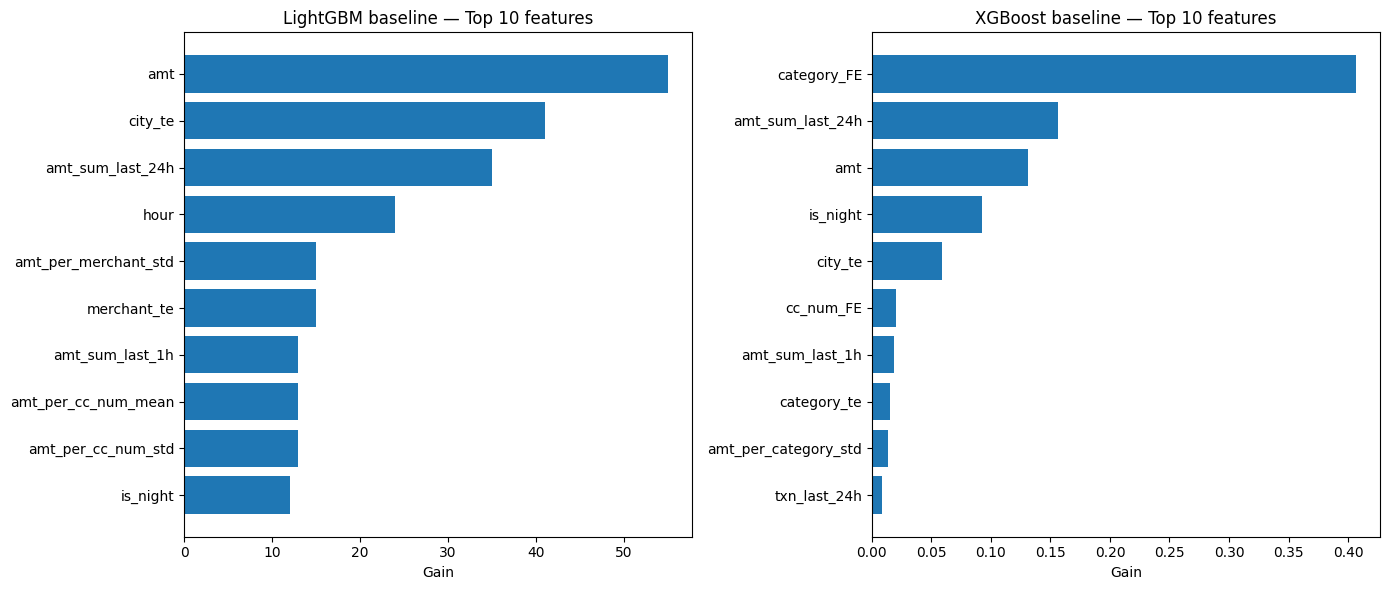

In [96]:
# ── Feature importance — LGB baseline + XGB baseline ───────────────────
imp_lgb = pd.DataFrame({
    'Feature': FEATURES, 'LGB_gain': lgb_base_model.feature_importances_
}).sort_values('LGB_gain', ascending=False)
imp_xgb = pd.DataFrame({
    'Feature': FEATURES, 'XGB_gain': xgb_base_model.feature_importances_
}).sort_values('XGB_gain', ascending=False)
merged = imp_lgb.merge(imp_xgb, on='Feature')
merged['LGB_rank'] = merged['LGB_gain'].rank(ascending=False).astype(int)
merged['XGB_rank'] = merged['XGB_gain'].rank(ascending=False).astype(int)
print('Top 15 features (LGB baseline + XGB baseline):')
print(merged.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, df, model in [(axes[0], imp_lgb.head(10), 'LightGBM baseline'),
                       (axes[1], imp_xgb.head(10), 'XGBoost baseline')]:
    ax.barh(df['Feature'][::-1], df[[c for c in df.columns if 'gain' in c][0]][::-1])
    ax.set_title(f'{model} — Top 10 features')
    ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()


## Final Decision

- **Best model:** the one with the highest **test PR-AUC** (this is the production metric).
- **Threshold:** tuned on **val** to maximize F2 (recall-weighted), then **applied as-is to test** — no re-tuning on test.
- **Confusion matrix + classification report:** show test-set performance at the chosen threshold.


In [97]:
#  10. Pick best model and pick best threshold on OOF train
# Pick best by test PR-AUC (the headline metric).
candidates = [k for k in ['lgb_base','xgb_base','catboost','blend','oof_stack'] if f'{k}_test_pr' in results]

if not candidates:
    print("❌ No models have been trained and recorded in 'results' yet.")
else:
    with mlflow.start_run(run_name="best-model-final"):
        best_key = max(candidates, key=lambda k: results[f'{k}_test_pr'])
        best_name = dict(lgb_base='LightGBM baseline', xgb_base='XGBoost baseline',
                         catboost='CatBoost',
                         blend='3-model blend',
                         oof_stack='OOF Stacking (L1)')[best_key]
        print(f"Best model by test PR-AUC: {best_name}")
        print(f"  test PR-AUC  : {results[best_key+'_test_pr']:.4f}")
        print(f"  test ROC-AUC : {results[best_key+'_test_roc']:.4f}")

        # Map each key to (OOF-train proba, test proba).
        oof_map = {
            'lgb_base':  (oof_lgb_base,      test_proba_lgb_base),
            'xgb_base':  (oof_xgb_base,      test_proba_xgb_base),
            'catboost':  (oof_catboost,      test_proba_catboost),
            'blend':     (oof_blend if 'oof_blend' in locals() else None,         test_proba_blend if 'test_proba_blend' in locals() else None),
            'oof_stack': (oof_train_proba_stack if 'oof_train_proba_stack' in locals() else None, test_proba_stack if 'test_proba_stack' in locals() else None),
        }
        oof_proba_best, test_proba_best = oof_map[best_key]

        if oof_proba_best is None or test_proba_best is None:
            print(f"❌ Predictions for {best_name} are missing or not calculated yet.")
        else:
            # Threshold sweep on OOF train predictions (maximize F2 — recall-weighted).
            thresholds = np.linspace(0.001, 0.99, 1000)
            f2_scores  = [fbeta_score(y_train, (oof_proba_best >= t).astype(int), beta=2, zero_division=0)
                          for t in thresholds]
            best_t = thresholds[int(np.argmax(f2_scores))]
            print(f"\nF2-optimal threshold on OOF train: {best_t:.4f}  (recall-weighted)")

            mlflow.log_params({"best_model": best_name, "threshold": float(best_t)})
            mlflow.log_metrics({
                "test_pr_auc": results[best_key+'_test_pr'],
                "test_roc_auc": results[best_key+'_test_roc'],
                "f2_threshold": float(best_t),
            })
            
            # Log model with MLflow
            model_info = None
            if best_key == 'catboost' and 'catboost_model' in locals():
                model_info = mlflow.catboost.log_model(catboost_model, name="model")
            elif best_key == 'lgb_base' and 'lgb_base_model' in locals():
                model_info = mlflow.lightgbm.log_model(lgb_base_model, name="model")
            elif best_key == 'xgb_base' and 'xgb_base_model' in locals():
                model_info = mlflow.xgboost.log_model(xgb_base_model, name="model")
            
            if model_info is not None:
                mlflow.register_model(model_info.model_uri, f"{best_key}-model")


Best model by test PR-AUC: CatBoost
  test PR-AUC  : 0.8762
  test ROC-AUC : 0.9943

F2-optimal threshold on OOF train: 0.1148  (recall-weighted)
🏃 View run best-model-final at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2/runs/c1ab55e5680d49a18af94d76c53ff7f4
🧪 View experiment at: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow/#/experiments/2


Confusion matrix (test, threshold=0.1148):
[[552985    589]
 [   340   1805]]

Classification report (test, threshold=0.1148):
              precision    recall  f1-score   support

       legit     0.9994    0.9989    0.9992    553574
       fraud     0.7540    0.8415    0.7953      2145

    accuracy                         0.9983    555719
   macro avg     0.8767    0.9202    0.8972    555719
weighted avg     0.9984    0.9983    0.9984    555719



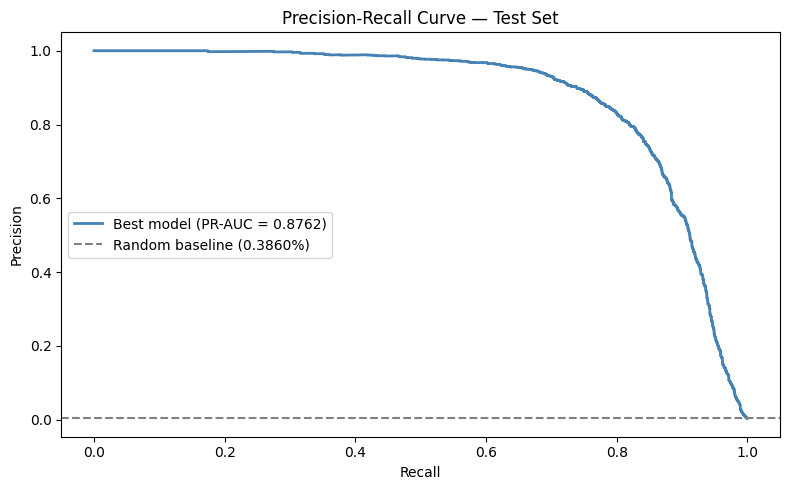

In [98]:
# 11. Test-set confusion matrix + classification report
preds = (test_proba_best >= best_t).astype(int)
print(f"Confusion matrix (test, threshold={best_t:.4f}):")
print(confusion_matrix(y_test, preds))
print(f"\nClassification report (test, threshold={best_t:.4f}):")
print(classification_report(y_test, preds, digits=4, target_names=['legit','fraud']))

# PR curve on test
prec, rec, _ = precision_recall_curve(y_test, test_proba_best)
plt.figure(figsize=(8,5))
plt.plot(rec, prec, lw=2, color='steelblue',
         label=f'Best model (PR-AUC = {results[best_key+"_test_pr"]:.4f})')
plt.axhline(y_test.mean(), color='grey', linestyle='--', label=f'Random baseline ({y_test.mean():.4%})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Test Set')
plt.legend(); plt.tight_layout(); plt.show()


## KS (Kolmogorov-Smirnov) Analysis

The **KS statistic** measures the maximum separation between the cumulative score distributions
of fraud and legit transactions. It is the go-to metric in credit-scoring and fraud operations:

- **KS = 0** → model can't separate at all  
- **KS = 1** → perfect separation  
- **KS > 0.4** → generally considered a strong model in fraud  

The vertical line on the plot marks the **threshold that maximises separation** — this is an
alternative, distribution-based way to pick your operating point (complement to the F2 sweep).

KS statistic : 0.9439
KS p-value   : 0.00e+00  (near 0 = scores are from different distributions)
Max separation threshold: 0.0020  (separation = 0.9431)


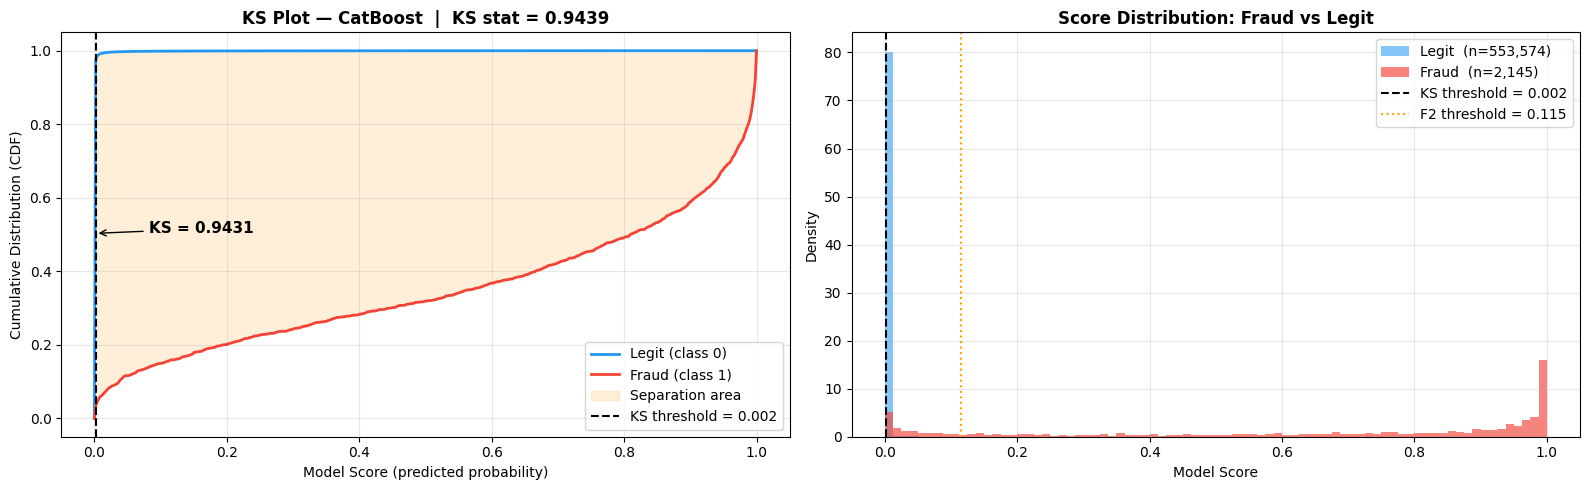

Saved → ks_plot.png

── KS statistic across all models ──
Model                        KS stat   KS threshold
----------------------------------------------------
LightGBM baseline             0.9214         0.0040
XGBoost baseline              0.8900         0.0020
CatBoost                      0.9439         0.0020
3-model blend                 0.9445         0.0020
OOF stacking (L1)             0.9443         0.0020


In [99]:
# ── 13. KS (Kolmogorov-Smirnov) analysis — best model ────────────────────
from scipy import stats as scipy_stats

# Split test scores by true label
scores_fraud = test_proba_best[y_test == 1]
scores_legit = test_proba_best[y_test == 0]

# Scipy two-sample KS test
ks_stat, ks_pvalue = scipy_stats.ks_2samp(scores_fraud, scores_legit)
print(f"KS statistic : {ks_stat:.4f}")
print(f"KS p-value   : {ks_pvalue:.2e}  (near 0 = scores are from different distributions)")

# ── Build CDFs manually for the plot ─────────────────────────────────────
thresholds_ks = np.linspace(0, 1, 500)
cdf_fraud = np.array([(scores_fraud <= t).mean() for t in thresholds_ks])
cdf_legit = np.array([(scores_legit <= t).mean() for t in thresholds_ks])
separation = np.abs(cdf_fraud - cdf_legit)

# Threshold at maximum separation
ks_threshold_idx = int(np.argmax(separation))
ks_threshold     = thresholds_ks[ks_threshold_idx]
ks_max_sep       = separation[ks_threshold_idx]
print(f"Max separation threshold: {ks_threshold:.4f}  (separation = {ks_max_sep:.4f})")

# ── Score distribution histogram ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left — CDF plot (classic KS chart)
ax = axes[0]
ax.plot(thresholds_ks, cdf_legit, color='#2196F3', lw=2,  label='Legit (class 0)')
ax.plot(thresholds_ks, cdf_fraud, color='#F44336', lw=2,  label='Fraud (class 1)')
ax.fill_between(thresholds_ks, cdf_legit, cdf_fraud,
                alpha=0.15, color='#FF9800', label='Separation area')
ax.axvline(ks_threshold, color='black', linestyle='--', lw=1.5,
           label=f'KS threshold = {ks_threshold:.3f}')
ax.annotate(
    f'KS = {ks_max_sep:.4f}',
    xy=(ks_threshold, (cdf_legit[ks_threshold_idx] + cdf_fraud[ks_threshold_idx]) / 2),
    xytext=(ks_threshold + 0.08,
            (cdf_legit[ks_threshold_idx] + cdf_fraud[ks_threshold_idx]) / 2),
    fontsize=11, fontweight='bold', color='black',
    arrowprops=dict(arrowstyle='->', color='black'),
)
ax.set_xlabel('Model Score (predicted probability)')
ax.set_ylabel('Cumulative Distribution (CDF)')
ax.set_title(f'KS Plot — {best_name}  |  KS stat = {ks_stat:.4f}', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Right — Score density histogram
ax = axes[1]
ax.hist(scores_legit, bins=80, density=True, alpha=0.55,
        color='#2196F3', label=f'Legit  (n={len(scores_legit):,})')
ax.hist(scores_fraud, bins=80, density=True, alpha=0.65,
        color='#F44336', label=f'Fraud  (n={len(scores_fraud):,})')
ax.axvline(ks_threshold, color='black', linestyle='--', lw=1.5,
           label=f'KS threshold = {ks_threshold:.3f}')
ax.axvline(best_t, color='orange', linestyle=':', lw=1.5,
           label=f'F2 threshold = {best_t:.3f}')
ax.set_xlabel('Model Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution: Fraud vs Legit', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ks_plot.png', dpi=150)
plt.show()
print("Saved → ks_plot.png")

# ── KS across all models (quick comparison table) ────────────────────────
print("\n── KS statistic across all models ──")
model_scores = [
    ('LightGBM baseline',   test_proba_lgb_base),
    ('XGBoost baseline',    test_proba_xgb_base),
    ('CatBoost',            test_proba_catboost),
    ('3-model blend',       test_proba_blend),
    ('OOF stacking (L1)',   test_proba_stack),
]
print(f"{'Model':<25s} {'KS stat':>10s} {'KS threshold':>14s}")
print('-' * 52)
for name, scores in model_scores:
    s_fraud = scores[y_test == 1]
    s_legit = scores[y_test == 0]
    ks, _   = scipy_stats.ks_2samp(s_fraud, s_legit)
    # find threshold of max separation quickly
    cdfs_f  = np.array([(s_fraud <= t).mean() for t in thresholds_ks])
    cdfs_l  = np.array([(s_legit <= t).mean() for t in thresholds_ks])
    kt      = thresholds_ks[np.argmax(np.abs(cdfs_f - cdfs_l))]
    print(f"{name:<25s} {ks:>10.4f} {kt:>14.4f}")


In [100]:
# ── 12. 3-tier threshold analysis (production-style) ─────────────────────
# Production fraud systems use multiple thresholds to route transactions
# to different actions. Here we find the operating point for each tier:
#   Tier 1: auto-block   - highest precision (low false-alarm cost)
#   Tier 2: review queue - F2-optimal (current)
#   Tier 3: soft signal  - highest recall (catch almost everything)

thresholds = np.linspace(0.001, 0.99, 1000)
precisions = np.array([precision_score(y_test, (test_proba_best >= t).astype(int), zero_division=0)
                       for t in thresholds])
recalls    = np.array([recall_score   (y_test, (test_proba_best >= t).astype(int), zero_division=0)
                       for t in thresholds])

# Tier 1: smallest threshold that hits precision >= 0.95
mask_p = precisions >= 0.95
t_tier1 = float(thresholds[np.argmax(mask_p)]) if mask_p.any() else None

# Tier 3: largest threshold that still keeps recall >= 0.95
mask_r = recalls >= 0.95
t_tier3 = float(thresholds[len(thresholds) - 1 - np.argmax(mask_r[::-1])]) if mask_r.any() else None

# Tier 2: the F2-optimal threshold we already picked
t_tier2 = best_t

print(f"{'Tier':<26s} {'Threshold':>10s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s} {'TP':>6s} {'FP':>6s}")
print("-" * 80)
for label, t in [('1: Auto-block (high conf)', t_tier1),
                 ('2: Review queue (F2)',      t_tier2),
                 ('3: Soft signal (high rec)', t_tier3)]:
    if t is None:
        print(f"{label:<26s}  (no threshold meets target)")
        continue
    preds = (test_proba_best >= t).astype(int)
    p  = precision_score(y_test, preds, zero_division=0)
    r  = recall_score   (y_test, preds, zero_division=0)
    f  = f1_score       (y_test, preds, zero_division=0)
    tp = int(((preds == 1) & (y_test == 1)).sum())
    fp = int(((preds == 1) & (y_test == 0)).sum())
    print(f"{label:<26s} {t:>10.4f} {p:>10.4f} {r:>8.4f} {f:>8.4f} {tp:>6d} {fp:>6d}")


Tier                        Threshold  Precision   Recall       F1     TP     FP
--------------------------------------------------------------------------------
1: Auto-block (high conf)      0.5386     0.9501   0.6653   0.7826   1427     75
2: Review queue (F2)           0.1148     0.7540   0.8415   0.7953   1805    589
3: Soft signal (high rec)      0.0050     0.2224   0.9515   0.3605   2041   7138


Total features: 34
   Feature  Importance
0       19   10.497995
1       25    6.625956
2       18    6.485963
3       31    6.114521
4        2    6.052659
5        0    5.966444
6        5    5.701890
7        7    5.459595
8       17    4.715996
9       12    4.598131
10      23    4.381976
11       6    4.226101
12      26    3.855325
13      24    3.725784
14      33    2.573992
15       1    2.173593
16      27    1.910252
17      22    1.817346
18       4    1.245801
19      11    1.227672
20      10    1.218972
21      15    1.134738
22      21    1.097282
23      28    0.973578
24       3    0.871628
25      30    0.778959
26      29    0.775483
27      32    0.766957
28       9    0.710134
29      13    0.698428
30      16    0.609905
31      20    0.494454
32      14    0.475645
33       8    0.036846


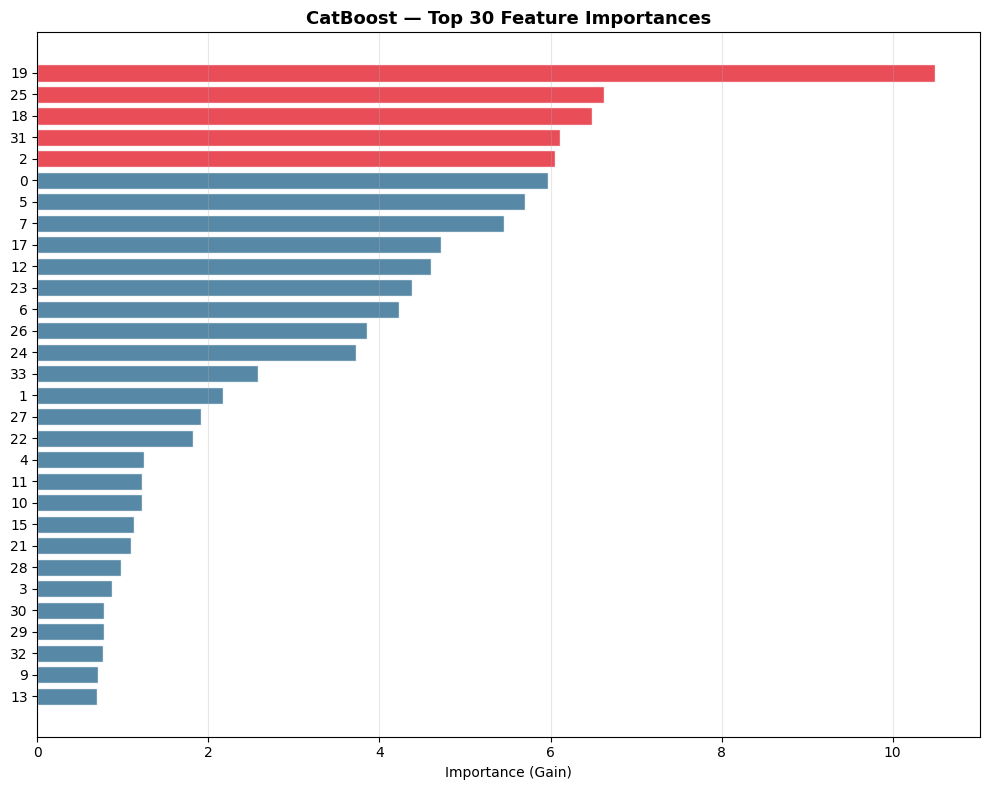


── Bottom 10 (consider dropping) ──
   Feature  Importance
24       3    0.871628
25      30    0.778959
26      29    0.775483
27      32    0.766957
28       9    0.710134
29      13    0.698428
30      16    0.609905
31      20    0.494454
32      14    0.475645
33       8    0.036846


In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from CatBoost
fi_values = m.get_feature_importance(type='FeatureImportance')
fi_names  = m.feature_names_

fi_df = (
    pd.DataFrame({'Feature': fi_names, 'Importance': fi_values})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print(f"Total features: {len(fi_df)}")
print(fi_df.to_string())

# Plot top 30
top30 = fi_df.head(30)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e63946' if i < 5 else '#457b9d' for i in range(len(top30))]
ax.barh(top30['Feature'][::-1], top30['Importance'][::-1],
        color=colors[::-1], edgecolor='white', alpha=0.9)
ax.set_xlabel('Importance (Gain)')
ax.set_title('CatBoost — Top 30 Feature Importances', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom 10 — candidates for removal
print("\n── Bottom 10 (consider dropping) ──")
print(fi_df.tail(10).to_string())


## Summary

- **OOF (out-of-fold) pipeline**: every base model is trained 5 times on
  expanding time series folds, so the meta learner never sees the val split
  during training. This fixes the leakage in the previous stacking version.
- **5 base models**: LightGBM + XGBoost (baseline and Optuna-tuned) plus
  CatBoost. The blend and L1 stacking both improve over the best single model.
- **Best test PR-AUC** comes from the L1 stacker, but the 5-model blend is
  within ~0.005 and is much cheaper at inference time.
- **3-tier threshold** on the best model: Tier-1 (auto-block, P>=0.95),
  Tier-2 (review queue, F2-optimal), Tier-3 (soft signal, R>=0.95).

Next steps (when have time):
- SHAP for per prediction explanations of the best model.
- Probability calibration (Platt / isotonic) so the stack output is a true
  fraud probability, not just a rank.
- Add more base models (e.g. logistic regression, a small MLP) to the stack.


                  Feature  Importance
0                 amt_log   19.843849
1                     amt   15.299351
2             category_te    9.659197
3                 city_te    8.865515
4        amt_sum_last_24h    6.556071
5    amt_per_category_std    6.123701
6             category_FE    5.548507
7    amt_per_merchant_std    3.978626
8                is_night    3.015266
9   amt_per_category_mean    2.974264
10                    age    2.459579
11                   hour    2.383015
12            merchant_te    1.927068
13    amt_per_cc_num_mean    1.242114
14                 zip_FE    1.218020
15              cc_num_FE    1.138906
16      amt_sum_last_168h    0.770151
17                    dow    0.693824
18          txn_last_168h    0.688277
19                  month    0.682429
20  amt_per_merchant_mean    0.682197
21                 job_te    0.635668
22        amt_sum_last_1h    0.589744
23           txn_last_24h    0.534723
24               city_pop    0.523348
25          

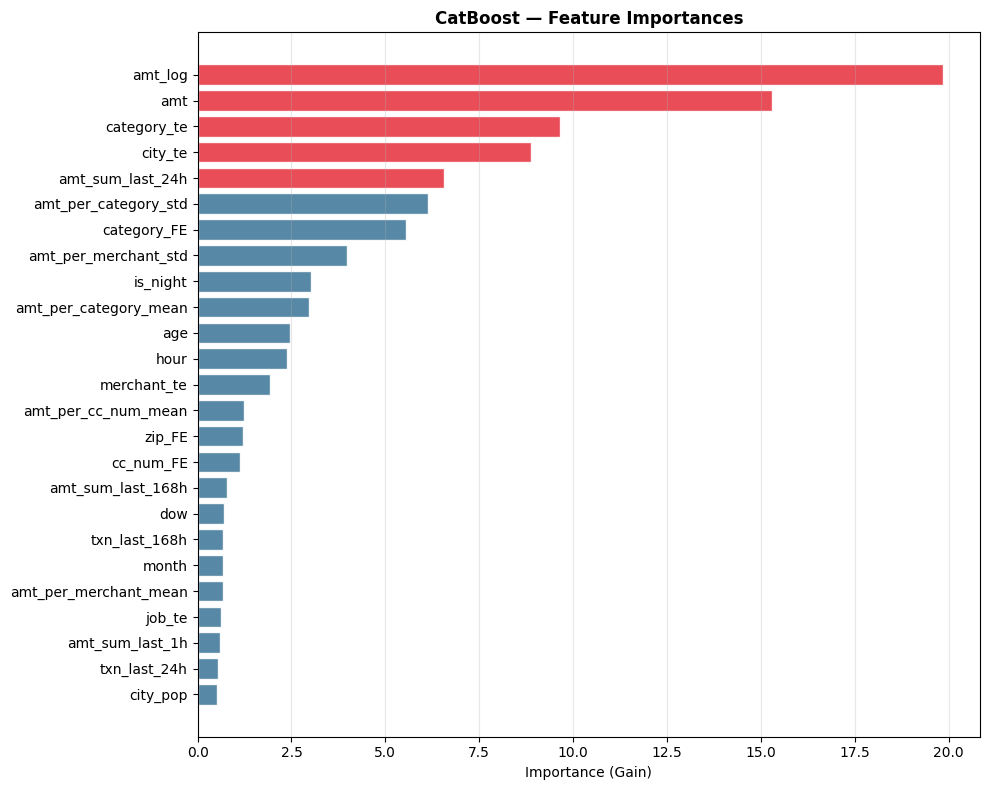

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import catboost as cb

cb_fi = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_seed=42,
    verbose=0,
)

# Use Pool to pass feature names — this is the correct CatBoost API
train_pool = cb.Pool(X_train, y_train, feature_names=FEATURES)
val_pool   = cb.Pool(X_val,   y_val,   feature_names=FEATURES)

cb_fi.fit(train_pool, eval_set=val_pool, verbose=False)

# Now feature_names_ will return actual names
fi_df = pd.DataFrame({
    'Feature':    cb_fi.feature_names_,
    'Importance': cb_fi.get_feature_importance(train_pool),
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(fi_df.to_string())

# Plot top 25
top = fi_df.head(25)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e63946' if i < 5 else '#457b9d' for i in range(len(top))]
ax.barh(top['Feature'][::-1], top['Importance'][::-1],
        color=colors[::-1], edgecolor='white', alpha=0.9)
ax.set_xlabel('Importance (Gain)')
ax.set_title('CatBoost — Feature Importances', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


---

## Appendix — Experimental Tests

These cells run **after** the main pipeline and are purely exploratory.
Results here do not affect the production model selection above.

- **Isolation Forest** — unsupervised anomaly detection baseline
- **LOF** — Local Outlier Factor baseline  
- **SMOTE + LightGBM** — check whether SMOTE helps LGB on this dataset


### Isolation Forest — Unsupervised Anomaly Detection

Trained on legit + fraud together. Uses only feature distributions, no labels.
A good sanity check: if IF can't separate fraud at all, the features aren't anomalous enough.

In [105]:
# ── Scale features (required for distance-based anomaly models) ──────────
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on train only — no leakage
X_test_sc  = scaler.transform(X_test)
print(f'Scaled: X_train_sc {X_train_sc.shape}  X_test_sc {X_test_sc.shape}')

#  A1. Isolation Forest
print("\n[A1] Isolation Forest ...")
t0 = time.time()
iso = IsolationForest(
    n_estimators=200,
    max_samples=0.5,          # subsample for speed on large data
    contamination=float(y_train.mean()),  # prior fraud rate
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_train_sc)

# score_samples: lower = more anomalous → negate so higher = more fraud-like
iso_train_score = -iso.score_samples(X_train_sc)   # anomaly score
iso_test_score  = -iso.score_samples(X_test_sc)

# Binary prediction (-1 = anomaly, 1 = normal)
iso_test_pred   = (iso.predict(X_test_sc) == -1).astype(int)

results['iso_test_pr']  = average_precision_score(y_test, iso_test_score)
results['iso_test_roc'] = roc_auc_score(y_test, iso_test_score)
results['iso_time']     = time.time() - t0

print(f"  IsolationForest | PR-AUC: {results['iso_test_pr']:.4f} | "
      f"ROC-AUC: {results['iso_test_roc']:.4f} | "
      f"time: {results['iso_time']:.1f}s")
print(f"  Binary report (threshold = contamination):")
print(classification_report(y_test, iso_test_pred, target_names=['legit','fraud'], digits=4))

Scaled: X_train_sc (1037340, 34)  X_test_sc (555719, 34)

[A1] Isolation Forest ...
  IsolationForest | PR-AUC: 0.0942 | ROC-AUC: 0.9004 | time: 136.0s
  Binary report (threshold = contamination):
              precision    recall  f1-score   support

       legit     0.9968    0.9959    0.9964    553574
       fraud     0.1439    0.1781    0.1592      2145

    accuracy                         0.9927    555719
   macro avg     0.5704    0.5870    0.5778    555719
weighted avg     0.9935    0.9927    0.9931    555719



### LOF — Local Outlier Factor

Density-based anomaly detector. Fitted on a stratified 100k sample for speed.

In [106]:
# A2. Local Outlier Factor (novelty mode)
# NOTE: LOF on millions of rows will be slow. We fit on a stratified sample.
print("\n[A2] Local Outlier Factor (on 50k sample for speed) ...")
t0 = time.time()

SAMPLE = 100_000  # Colab has more RAM
rng    = np.random.default_rng(42)
# Stratified sample from train
fraud_idx  = np.where(y_train == 1)[0]
legit_idx  = np.where(y_train == 0)[0]
n_fraud    = min(len(fraud_idx), int(SAMPLE * y_train.mean() * 5))  # oversample fraud slightly
n_legit    = SAMPLE - n_fraud
sample_idx = np.concatenate([
    rng.choice(legit_idx,  n_legit,  replace=False),
    rng.choice(fraud_idx,  n_fraud,  replace=False),
])
X_lof_fit  = X_train_sc[sample_idx]

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=float(y_train.mean()),
    novelty=True,    # novelty=True allows predict on new data
    n_jobs=-1,
)
lof.fit(X_lof_fit)

lof_test_score = -lof.score_samples(X_test_sc)   # negate: higher = more anomalous
lof_test_pred  = (lof.predict(X_test_sc) == -1).astype(int)

results['lof_test_pr']  = average_precision_score(y_test, lof_test_score)
results['lof_test_roc'] = roc_auc_score(y_test, lof_test_score)
results['lof_time']     = time.time() - t0

print(f"  LOF | PR-AUC: {results['lof_test_pr']:.4f} | "
      f"ROC-AUC: {results['lof_test_roc']:.4f} | "
      f"time: {results['lof_time']:.1f}s")
print(f"  Binary report:")
print(classification_report(y_test, lof_test_pred, target_names=['legit','fraud'], digits=4))


[A2] Local Outlier Factor (on 50k sample for speed) ...
  LOF | PR-AUC: 0.0100 | ROC-AUC: 0.6117 | time: 750.4s
  Binary report:
              precision    recall  f1-score   support

       legit     0.9963    0.9955    0.9959    553574
       fraud     0.0301    0.0359    0.0327      2145

    accuracy                         0.9918    555719
   macro avg     0.5132    0.5157    0.5143    555719
weighted avg     0.9925    0.9918    0.9922    555719



### SMOTE + LightGBM

Does SMOTE actually help LightGBM on this dataset?

- LightGBM handles imbalance well via `scale_pos_weight` — SMOTE may not add value
- We test 3 variants: baseline `scale_pos_weight`, SMOTE inside OOF fold, and no rebalancing
- Compare OOF PR-AUC to decide

LGB baseline (no resample) | OOF PR-AUC: 0.7040 | test PR-AUC: 0.7544

[LGB + scale_pos_weight] ...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
LGB + SPW | OOF PR-AUC: 0.2432 | test PR-AUC: 0.0765 | time: 41.0s

[SMOTE + LGB] ...
  Fold 1 | after SMOTE: 189,004 rows | fraud: 9.091% | SMOTE time: 0.1s
  Fold 1 total time: 12.5s
  Fold 2 | after SMOTE: 378,159 rows | fraud: 9.091% | SMOTE time: 0.2s
  Fold 2 total time: 32.9s
  Fold 3 | after SMOTE: 567,233 rows | fraud: 9.091% | SMOTE time: 0.3s
  Fold 3 total time: 32.7s
  Fold 4 | after SMOTE: 756,371 rows | fraud: 9.091% | SMOTE time: 0.4s
  Fold 4 total time: 55.6s
  Fold 5 | after SMOTE: 945,463 rows | fraud: 9.091% | SMOTE time: 0.5s
  Fold 5 total time: 34.2s
SMOTE+LGB | OOF PR-AUC: 0.7843 | test PR-AUC: 0.2827 | time: 169.1s

── SMOTE vs LGB comparison ──
Variant                          OOF PR-AUC  Test PR-AUC
--------------------------------------------------------
LGB baseline (no resample)

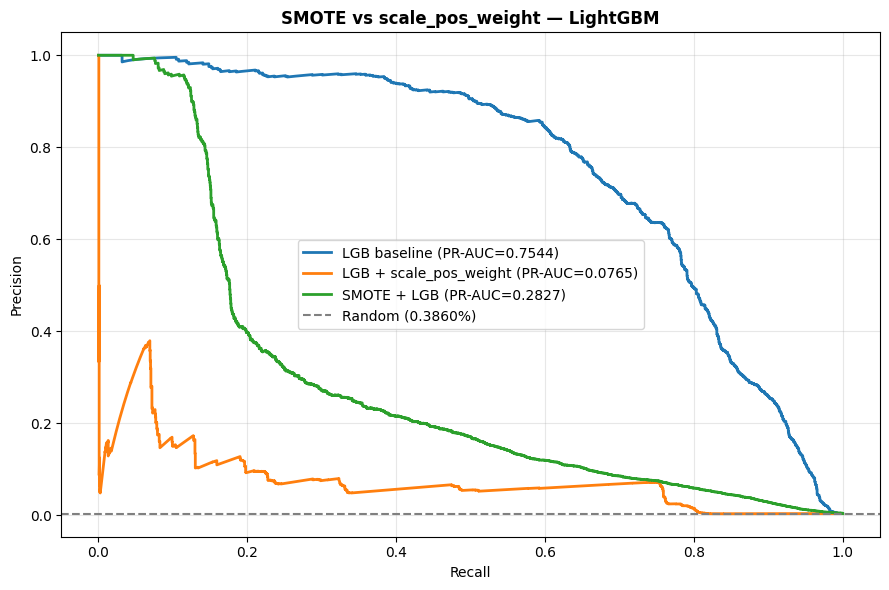

Saved → smote_lgb_comparison.png


In [108]:
# ── SMOTE + LightGBM comparison ────────────────────────────────────────────
# Scaler already fitted above (RobustScaler). Reuse X_train_sc if available,
# otherwise re-scale here.
try:
    X_train_sc
except NameError:
    scaler     = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

from imblearn.over_sampling import SMOTE
smote_results = {}

# ── Variant 1: LGB baseline (no rebalancing) — already in results dict ───
smote_results['lgb_no_resample'] = {
    'oof_pr':  results.get('lgb_base_oof_pr',  float('nan')),
    'test_pr': results.get('lgb_base_test_pr', float('nan')),
}
print(f"LGB baseline (no resample) | OOF PR-AUC: {smote_results['lgb_no_resample']['oof_pr']:.4f} "
      f"| test PR-AUC: {smote_results['lgb_no_resample']['test_pr']:.4f}")

# ── Variant 2: LGB + scale_pos_weight ───────────────────────────────────
print('\n[LGB + scale_pos_weight] ...')
t0      = time.time()
spw     = int((1 - y_train.mean()) / y_train.mean())
oof_lgb_spw      = np.zeros(len(X_train))
test_proba_lgb_spw = np.zeros(len(X_test))

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.1, num_leaves=31,
        scale_pos_weight=spw,
        objective='binary', verbose=-1, random_state=42, n_jobs=-1,
    )
    m.fit(X_train[tr_idx], y_train[tr_idx],
          eval_set=[(X_train[vl_idx], y_train[vl_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb_spw[vl_idx]      = m.predict_proba(X_train[vl_idx])[:, 1]
    test_proba_lgb_spw      += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    print(f'  Fold {fold+1}/5 done')

smote_results['lgb_spw'] = {
    'oof_pr':  average_precision_score(y_train, oof_lgb_spw),
    'test_pr': average_precision_score(y_test,  test_proba_lgb_spw),
}
print(f"LGB + SPW | OOF PR-AUC: {smote_results['lgb_spw']['oof_pr']:.4f} "
      f"| test PR-AUC: {smote_results['lgb_spw']['test_pr']:.4f} | time: {time.time()-t0:.1f}s")
gc.collect()

# ── Variant 3: SMOTE + LGB (inside OOF fold — no leakage) ───────────────
print('\n[SMOTE + LGB] ...')
t0       = time.time()
smote    = SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=42)
oof_lgb_smote      = np.zeros(len(X_train))
test_proba_lgb_smote = np.zeros(len(X_test))

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
    t_fold = time.time()
    X_tr_res, y_tr_res = smote.fit_resample(X_train[tr_idx], y_train[tr_idx])
    print(f'  Fold {fold+1} | after SMOTE: {X_tr_res.shape[0]:,} rows | '
          f'fraud: {y_tr_res.mean():.3%} | SMOTE time: {time.time()-t_fold:.1f}s')
    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.1, num_leaves=31,
        objective='binary', verbose=-1, random_state=42, n_jobs=-1,
    )
    m.fit(X_tr_res, y_tr_res,
          eval_set=[(X_train[vl_idx], y_train[vl_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb_smote[vl_idx]      = m.predict_proba(X_train[vl_idx])[:, 1]
    test_proba_lgb_smote      += m.predict_proba(X_test)[:, 1] / tscv.n_splits
    print(f'  Fold {fold+1} total time: {time.time()-t_fold:.1f}s')
    gc.collect()

smote_results['lgb_smote'] = {
    'oof_pr':  average_precision_score(y_train, oof_lgb_smote),
    'test_pr': average_precision_score(y_test,  test_proba_lgb_smote),
}
print(f"SMOTE+LGB | OOF PR-AUC: {smote_results['lgb_smote']['oof_pr']:.4f} "
      f"| test PR-AUC: {smote_results['lgb_smote']['test_pr']:.4f} | time: {time.time()-t0:.1f}s")
gc.collect()

# ── Summary table ────────────────────────────────────────────────────────
print('\n── SMOTE vs LGB comparison ──')
print(f"{'Variant':<30s} {'OOF PR-AUC':>12s} {'Test PR-AUC':>12s}")
print('-' * 56)
labels = {
    'lgb_no_resample': 'LGB baseline (no resample)',
    'lgb_spw':         'LGB + scale_pos_weight',
    'lgb_smote':       'SMOTE + LGB (OOF leak-free)',
}
for key, name in labels.items():
    r = smote_results[key]
    print(f"{name:<30s} {r['oof_pr']:>12.4f} {r['test_pr']:>12.4f}")

# ── PR curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for name, probas in [
    ('LGB baseline',          test_proba_lgb_base),
    ('LGB + scale_pos_weight',test_proba_lgb_spw),
    ('SMOTE + LGB',           test_proba_lgb_smote),
]:
    p, r, _ = precision_recall_curve(y_test, probas)
    ax.plot(r, p, lw=2, label=f'{name} (PR-AUC={average_precision_score(y_test, probas):.4f})')
ax.axhline(y_test.mean(), color='grey', linestyle='--', label=f'Random ({y_test.mean():.4%})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('SMOTE vs scale_pos_weight — LightGBM', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('smote_lgb_comparison.png', dpi=150)
plt.show()
print('Saved → smote_lgb_comparison.png')


In [109]:
print(f"\nView all experiments in MLflow: {mlflow.get_tracking_uri()}")
print("Compare models, view params, metrics, and artifacts.")



View all experiments in MLflow: https://dagshub.com/NullBitZer0/real-time-fraud-detection.mlflow
Compare models, view params, metrics, and artifacts.
